=== DATASET COLUMNS ===
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales']

=== SUMMARY STATISTICS ===
            row_id   postal_code         sales
count  9800.000000   9800.000000   9800.000000
mean   4900.500000  55276.498571    230.769059
std    2829.160653  32023.374393    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


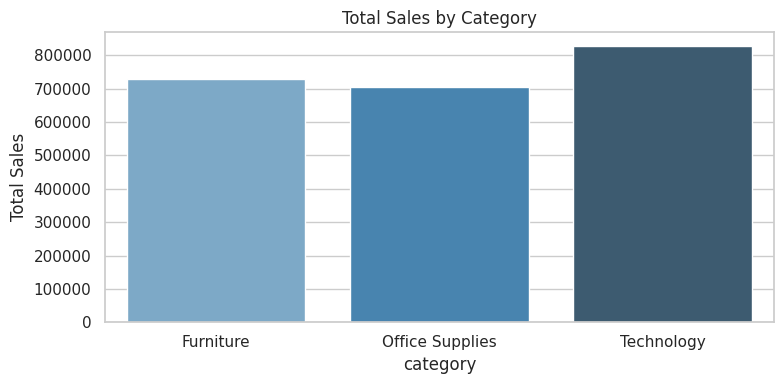

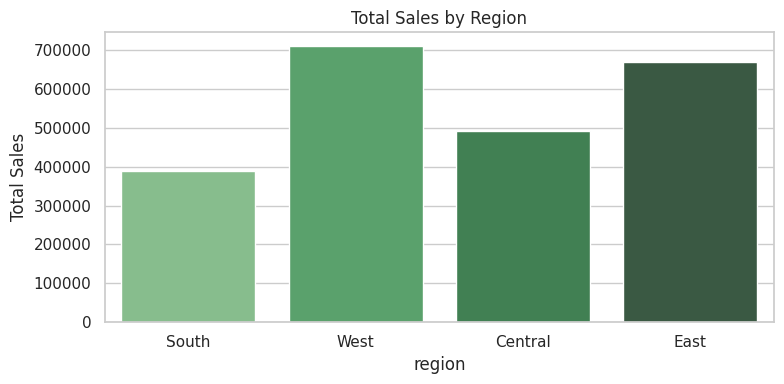

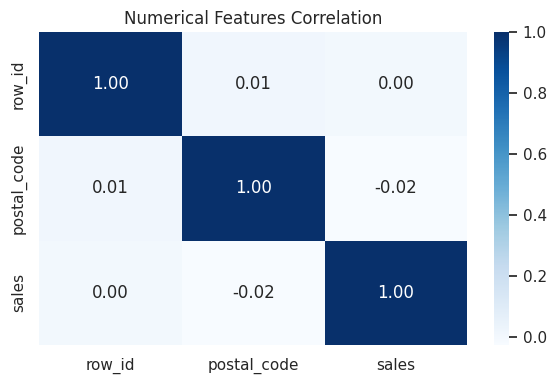


EDA Completed and All Charts Saved Successfully!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("SWYNEX_Cleaned_Data.csv")

df.columns = df.columns.str.lower().str.strip()

print("=== DATASET COLUMNS ===")
print(df.columns.tolist())

print("\n=== SUMMARY STATISTICS ===")
print(df.describe())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='category', y='sales', estimator=sum, errorbar=None, hue='category', legend=False, palette='Blues_d')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('sales_by_category.png')
plt.show()

if 'region' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x='region', y='sales', estimator=sum, errorbar=None, hue='region', legend=False, palette='Greens_d')
    plt.title('Total Sales by Region')
    plt.ylabel('Total Sales')
    plt.tight_layout()
    plt.savefig('sales_by_region.png')
    plt.show()

if 'sub_category' in df.columns:
    plt.figure(figsize=(10, 5))
    subcat_sales = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=subcat_sales.values, y=subcat_sales.index, hue=subcat_sales.index, legend=False, palette='Viridis')
    plt.title('Top 10 Sub-Categories by Sales')
    plt.xlabel('Total Sales')
    plt.tight_layout()
    plt.savefig('top_subcategories.png')
    plt.show()

plt.figure(figsize=(6, 4))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Numerical Features Correlation')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print("\nEDA Completed and All Charts Saved Successfully!")